In [1]:
import pandas as pd


# Load CSV file
df = pd.read_csv("Nat_Gas.csv")

# Show first 5 rows
print(df.head())

      Dates  Prices
0  10/31/20    10.1
1  11/30/20    10.3
2  12/31/20    11.0
3   1/31/21    10.9
4   2/28/21    10.9


In [2]:
df['Dates'] = pd.to_datetime(df['Dates'])

Check Dataset Information

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[ns]
 1   Prices  48 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 896.0 bytes
None


In [4]:
print(df.describe())

          Prices
count  48.000000
mean   11.207083
std     0.757897
min     9.840000
25%    10.650000
50%    11.300000
75%    11.625000
max    12.800000


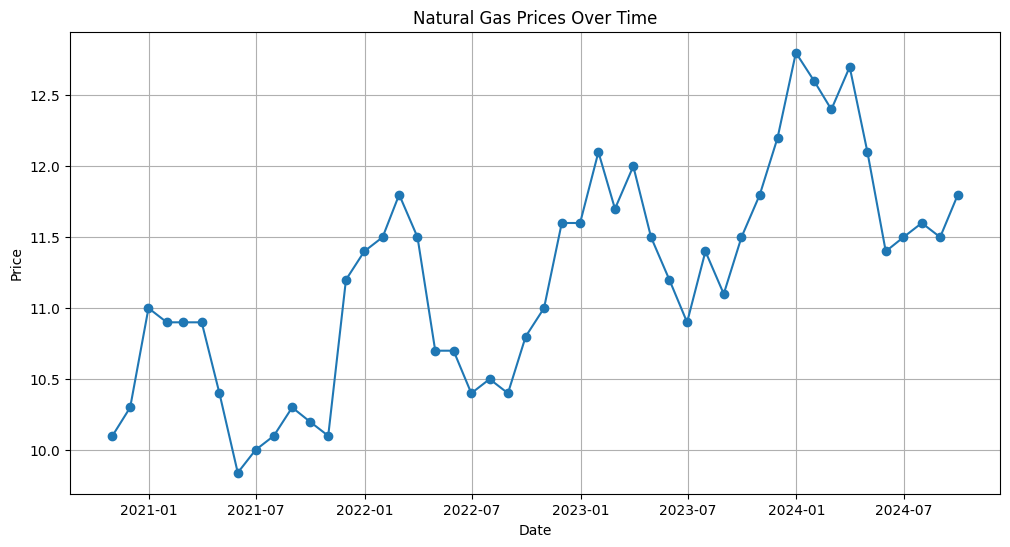

In [5]:
# Import matplotlib library for creating graphs and charts
import matplotlib.pyplot as plt

# Create a graph figure with custom size, 
# figsize = (width, height),Here width = 12 and height = 6
# This makes the graph bigger and easier to read
plt.figure(figsize=(12,6))

# Plot the graph using Dates on X-axis and Prices on Y-axis
# marker='o' adds small circles on each data point
plt.plot(df['Dates'], df['Prices'], marker='o')

# Add title to the graph
plt.title("Natural Gas Prices Over Time")

# Label for X-axis , Shows dates/months
# Label for Y-axis , Shows natural gas prices
plt.xlabel("Date")
plt.ylabel("Price")

# Add grid lines to make the graph easier to read
plt.grid(True)

# Display the final graph
plt.show()

In [6]:
# Create a new column called 'Days'
# This converts dates into number of days from the starting date

df['Days'] = (df['Dates'] - df['Dates'].min()).dt.days

Build Prediction Model use #linear regression
- Install scikit-learn library
- This library is used for machine learning and prediction models

In [7]:
!pip install scikit-learn

Q8. “Train the computer to understand how gas prices increase or decrease over time.”

In [8]:
# Import Linear Regression model from scikit-learn library
from sklearn.linear_model import LinearRegression

# X= input data(independent variable),Here we use the 'Days' column
# Double brackets are used because X should be in table format
X = df[['Days']]

# y = output data (dependent variable)
# Here we use Prices because we want to predict gas prices
y = df['Prices']

# Create the Linear Regression model
model = LinearRegression()

# The model learns & trained how prices change over time
model.fit(X, y)

LinearRegression()

In [9]:
# Create future day value for prediction
# Here 1800 means 1800 days after the starting date
future_days = [[1800]]

# Predict the gas price for that future day
# The trained model uses the trend it learned earlier
predicted_price = model.predict(future_days)

# Print the predicted future gas price
print(predicted_price)

[12.5993136]


c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


In [10]:
# Create a function to estimate gas price for any given date
def estimate_price(date):

     # Convert input into proper date format
    # This helps Python understand the date correctly
    date = pd.to_datetime(date)

    # Calculate how many days the input date is away from the first date
    # Example:
    # 2020-10-31 → 0 days
    # 2020-11-30 → 30 days
    days = (date - df['Dates'].min()).days

     # Predict the gas price using the trained regression model
    price = model.predict([[days]])

     # Return the predicted price rounded to 2 decimal places
    # Example: 12.4567 → 12.46
    return round(price[0], 2)

In [11]:
print(estimate_price("2025-06-30"))

12.47


c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


In [12]:
# Create future dates for prediction
# Start from the latest date in the dataset
future_dates = pd.date_range(
    
    # Start from the last available date
    start=df['Dates'].max(),
    
     # Create dates for next 12 months
    periods=12,
    
# 'M' means monthly frequency,It creates one date for each month
    freq='M'
)

# Convert future dates into number of days 
#because the model works with numeric values, not dates
future_days = (
     # Calculate difference from first date
    future_dates - df['Dates'].min()
    
    # Extract only the number of days
).days.values.reshape(-1,1)

# Predict future gas prices using the trained model
future_prices = model.predict(future_days)

c:\users\lenovo\appdata\local\programs\python\python37\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


Plot Historical + Forecast
Q13. “Show the past gas prices and also show what the prices may look like in the future.”

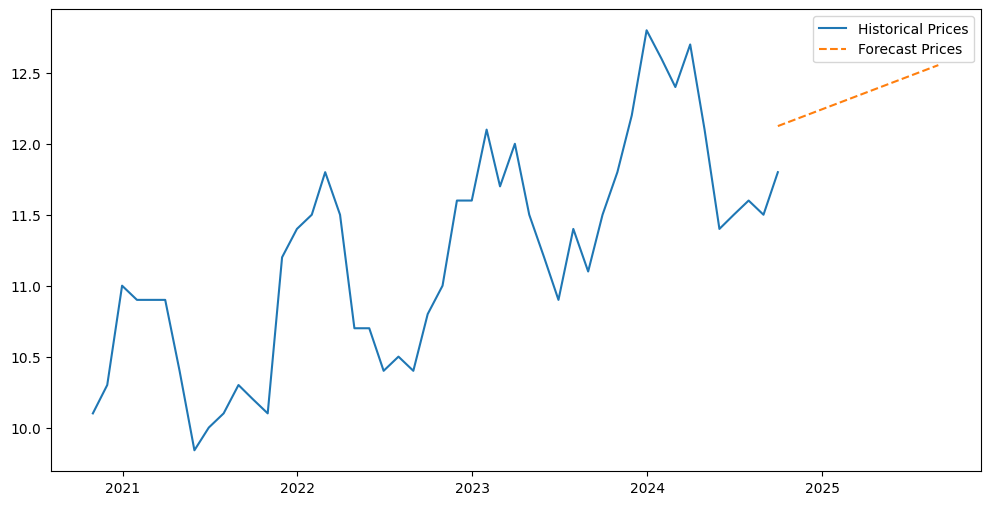

In [13]:
# Create a graph with custom size, Width = 12 and Height = 6
plt.figure(figsize=(12,6))

# Historical plot ,# X-axis = Dates, Y-axis = Prices
plt.plot(df['Dates'], df['Prices'],
         label='Historical Prices')  # Label for legend

# Plot forecasted future prices
# future_dates = predicted future months
# future_prices = predicted gas prices
plt.plot(future_dates, future_prices,
         
         # Dashed line style for forecast for predit not real
         linestyle='--',
         
         label='Forecast Prices')    # Label for legend

plt.legend()

plt.show()